In [1]:
import pandas as pd
import numpy as np
from zipfile import ZipFile

In [ ]:
zip = "/content/drive/MyDrive/animal-10.zip"

In [ ]:
with ZipFile(zip, 'r') as zip:
  zip.extractall()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
data_dir = "/content/raw-img"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 20947 images belonging to 10 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 5232 images belonging to 10 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])

model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,099,658 (15.64 MB)

 Trainable params: 1,841,674 (7.03 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1358s 2s/step - accuracy: 0.7995 - loss: 0.6515 - val_accuracy: 0.9220 - val_loss: 0.2453
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1336s 2s/step - accuracy: 0.9026 - loss: 0.3145 - val_accuracy: 0.9213 - val_loss: 0.2468
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1365s 2s/step - accuracy: 0.9081 - loss: 0.2942 - val_accuracy: 0.9255 - val_loss: 0.2364
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1347s 2s/step - accuracy: 0.9154 - loss: 0.2769 - val_accuracy: 0.9207 - val_loss: 0.2440
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1326s 2s/step - accuracy: 0.9123 - loss: 0.2787 - val_accuracy: 0.9323 - val_loss: 0.2163
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1328s 2s/step - accuracy: 0.9194 - loss: 0.2599 - val_accuracy: 0.9308 - val_loss: 0.2147
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1306s 2s/step - accuracy: 0.9198 - loss: 0.2520 - val_accuracy: 0.9279 - val_loss: 0.2280
Epoch 8/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 1396s 2s/step - accuracy: 0.9279 - loss: 0.2394 - 

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
model.evaluate(validation_generator)

164/164 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9389 - loss: 0.1991


[0.2140529751777649, 0.935206413269043]

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

In [ ]:
y_pred_prob = model.predict(validation_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

164/164 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step


In [ ]:
y_true = validation_generator.classes

In [ ]:
round(accuracy_score(y_true, y_pred), 2)

0.94

In [ ]:
from translate import translate

In [ ]:
class_names_fr = [
    translate[name]
    for name in validation_generator.class_indices.keys()
]

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names_fr))

              precision    recall  f1-score   support

       chien       0.91      0.95      0.93       972
      cheval       0.94      0.89      0.92       524
    éléphant       0.96      0.91      0.94       289
    papillon       0.98      0.94      0.96       422
       poule       0.95      0.97      0.96       619
        chat       0.97      0.87      0.92       333
       vache       0.83      0.91      0.87       373
      mouton       0.91      0.88      0.89       364
    araignée       0.98      0.98      0.98       964
    écureuil       0.92      0.95      0.93       372

    accuracy                           0.94      5232
   macro avg       0.94      0.93      0.93      5232
weighted avg       0.94      0.94      0.94      5232



In [ ]:
import matplotlib.pyplot as plt

<Figure size 1000x1000 with 0 Axes>

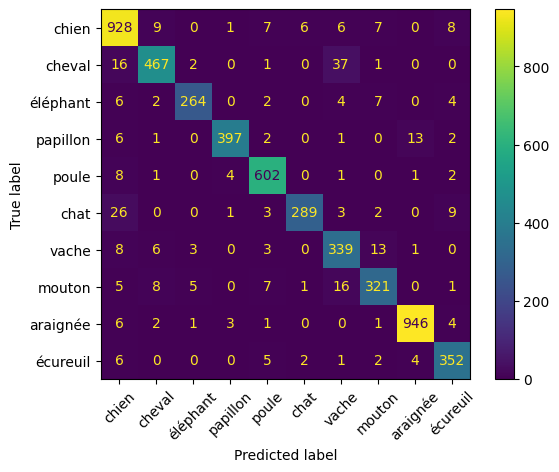

In [ ]:
plt.figure(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names_fr)
plt.xticks(rotation=45);

In [ ]:
model.save('animal-10.keras', include_optimizer=False)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
def predict_image(path, model, class_names_fr):
    img = image.load_img(path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred[0])
    confidence = np.max(pred[0])

    return class_names_fr[class_id], confidence

In [ ]:
label, conf = predict_image("/content/raw-img/gatto/100.jpeg", model, class_names_fr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


In [ ]:
label

'chat'

In [ ]:
conf

np.float32(0.9968894)

In [ ]:
class_names_fr

['chien',
 'cheval',
 'éléphant',
 'papillon',
 'poule',
 'chat',
 'vache',
 'mouton',
 'araignée',
 'écureuil']

In [2]:
import tensorflow as tf

In [4]:
np.__version__

'2.0.2'